# MODELOS DE MACHINE LEARNING

In [24]:
# IMPORTAR LIBRERIA
import polars as pl
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
import joblib
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from shapely.geometry import Point
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import copy


In [6]:
OUTPUT_DIR = "C:/Users/lesli/Documents/TFM/notebooks/ML_outputs"
# Creamos la carpeta automáticamente si no existe (exist_ok=True evita que lance error si ya existe)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Carpeta de almacenamiento lista en: '{OUTPUT_DIR}'")

Carpeta de almacenamiento lista en: 'C:/Users/lesli/Documents/TFM/notebooks/ML_outputs'


In [7]:
df_model = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")
df_model.head(5)

year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585,lon,lat,county,I_GDD,I_temp,I_precip,I_suelo,IAI
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,-120.703207,37.125374,"""Merced""",0.70784,1.0,0.0,0.55,0.572352
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,-119.113253,35.622238,"""Kern""",0.95056,1.0,0.0,0.391304,0.613429
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null,-121.880199,39.018031,"""Colusa""",1.0,1.0,0.0,0.666667,0.683333
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null,-119.128831,35.717057,"""Kern""",1.0,1.0,0.0,0.366667,0.623333
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null,-120.119889,37.04136,"""Madera""",1.0,1.0,0.0,0.591026,0.668205


In [8]:
columnas_a_eliminar = [
    "hurs_245", "hurs_585", "pr_245", "pr_585", 
    "referencia_base", "tmax_245", "tmax_585", 
    "tmean_245", "tmean_585", "tmin_245", "tmin_585", "es_proyeccion"
]# Calculamos el total de nulos por columna (mantiene los nombres originales de las variables)
df_model = df_model.drop(columnas_a_eliminar)
total_nulos = df_model.select(pl.all().null_count())

# Calculamos el porcentaje de nulos por columna
porcentaje_nulos = df_model.select((pl.all().null_count() / pl.count() * 100).round(2))

# tabla nulos (Nombre | Total | %)
df_nulls = pl.DataFrame({
    "Variable": df_model.columns,
    "Total Nulos": total_nulos.row(0),
    "% Nulos": porcentaje_nulos.row(0)
}).sort("Total Nulos", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(df_nulls)

C:\Users\lesli\AppData\Local\Temp\ipykernel_25224\4276885958.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  porcentaje_nulos = df_model.select((pl.all().null_count() / pl.count() * 100).round(2))


Variable,Total Nulos,% Nulos
str,i64,f64
"""sumbases_r""",425557,67.13
"""cec7_r""",35191,5.55
"""year""",0,0.0
"""crop_id""",0,0.0
"""crop_name""",0,0.0
"""is_target""",0,0.0
"""location""",0,0.0
"""processed""",0,0.0
"""ppt""",0,0.0


Hay una concentración masiva en el Valle Central y luego una cola larga de condados con muy pocas parcelas

# SPLIT DATASET

In [9]:
pl.Config.set_tbl_rows(60)  # mostrar hasta 60 filas
print(
    df_model
    .group_by('county')
    .len()
    .sort('len', descending=True)
)

shape: (57, 2)
┌─────────────────┬───────┐
│ county          ┆ len   │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ Fresno          ┆ 88309 │
│ Kern            ┆ 61125 │
│ Tulare          ┆ 48188 │
│ Merced          ┆ 40302 │
│ San Joaquin     ┆ 37916 │
│ Kings           ┆ 35259 │
│ Madera          ┆ 31017 │
│ Imperial        ┆ 28403 │
│ Stanislaus      ┆ 27273 │
│ Colusa          ┆ 25332 │
│ Yolo            ┆ 21504 │
│ Glenn           ┆ 20103 │
│ Butte           ┆ 19799 │
│ Sutter          ┆ 19163 │
│ Riverside       ┆ 16429 │
│ Mono            ┆ 11374 │
│ Modoc           ┆ 10537 │
│ Siskiyou        ┆ 10174 │
│ Lassen          ┆ 9870  │
│ Solano          ┆ 9006  │
│ Sacramento      ┆ 8662  │
│ Monterey        ┆ 8531  │
│ Yuba            ┆ 6476  │
│ San Luis Obispo ┆ 5151  │
│ Sonoma          ┆ 4787  │
│ Tehama          ┆ 4777  │
│ Napa            ┆ 3404  │
│ Santa Barbara   ┆ 3244  │
│ San Bernardino  ┆ 3227  │
│ Contra Costa    ┆ 2227  │
│ Pla

In [10]:
# ─────────────────────────────────────────────────────────
# SPLIT GEOGRÁFICO POR CONDADO (70 / 10 / 20)
# Train: Valle Central sur/centro (alta densidad)
# Val:   Valle Central norte + condados pequeños
# Test:  zonas geográficamente distintas + condados pequeños
# ─────────────────────────────────────────────────────────

condados_train = [
    'Fresno', 'Kern', 'Tulare', 'Merced', 'San Joaquin',
    'Kings', 'Madera', 'Imperial', 'Stanislaus', 'Colusa', 'Yolo'
]

condados_val = [
    'Glenn', 'Butte', 'Sutter', 'Sacramento',
    'Plumas', 'Mendocino', 'Lake', 'Shasta', 'Santa Clara',
    'Alpine', 'Santa Cruz', 'San Diego', 'El Dorado',
    'Calaveras', 'Marin', 'San Mateo', 'Nevada', 'Humboldt'
]

condados_test = [
    'Riverside', 'Mono', 'Modoc', 'Siskiyou', 'Lassen',
    'Solano', 'Monterey', 'Sonoma', 'Yuba', 'San Luis Obispo',
    'Napa', 'Santa Barbara', 'San Bernardino', 'Tehama',
    'Contra Costa', 'Placer', 'Inyo', 'San Benito', 'Ventura',
    'Alameda', 'Sierra', 'Amador', 'Los Angeles', 'Trinity',
    'Orange', 'Tuolumne', 'Mariposa', 'Del Norte'
]

# ── Crear columna split_zona ──
df_model = df_model.with_columns(
    pl.when(pl.col('county').is_in(condados_train))
      .then(pl.lit('train'))
      .when(pl.col('county').is_in(condados_val))
      .then(pl.lit('val'))
      .when(pl.col('county').is_in(condados_test))
      .then(pl.lit('test'))
      .otherwise(pl.lit('sin_asignar'))
      .alias('split_zona')
)

In [11]:
# ── Verificación de la distribución ──
resumen_split = (
    df_model
    .group_by('split_zona')
    .len()
    .sort('len', descending=True)
)

total = df_model.shape[0]
print("Distribución del split:")
print(f"{'Zona':<14} | {'Obs':>10} | {'%':>6}")
print('-' * 36)
for row in resumen_split.iter_rows(named=True):
    pct = 100 * row['len'] / total
    print(f"{row['split_zona']:<14} | {row['len']:>10,} | {pct:>5.1f}%")
print('-' * 36)
print(f"{'TOTAL':<14} | {total:>10,} | 100.0%")

# Verificar que no quedó nada sin asignar
sin_asignar = df_model.filter(pl.col('split_zona') == 'sin_asignar')
if sin_asignar.shape[0] > 0:
    print("\nADVERTENCIA: condados sin asignar:")
    print(sin_asignar.group_by('county').len().sort('len', descending=True))
else:
    print("\nTodos los condados asignados correctamente.")

Distribución del split:
Zona           |        Obs |      %
------------------------------------
train          |    444,628 |  70.1%
test           |    116,290 |  18.3%
val            |     73,034 |  11.5%
------------------------------------
TOTAL          |    633,952 | 100.0%

Todos los condados asignados correctamente.


In [12]:
# ── Verificar que ningún condado aparece en más de un split ──
solapamiento_tv = set(condados_train) & set(condados_val)
solapamiento_tt = set(condados_train) & set(condados_test)
solapamiento_vt = set(condados_val) & set(condados_test)

print("Verificación de solapamiento entre splits:")
print(f"  Train ∩ Val:  {solapamiento_tv or 'ninguno'}")
print(f"  Train ∩ Test: {solapamiento_tt or 'ninguno'}")
print(f"  Val ∩ Test:   {solapamiento_vt or 'ninguno'}")

# Verificar cobertura total de condados
todos_asignados = set(condados_train) | set(condados_val) | set(condados_test)
condados_datos = set(df_model['county'].unique().to_list())
faltantes = condados_datos - todos_asignados
print(f"\n  Condados en datos no asignados: {faltantes or 'ninguno'}")

Verificación de solapamiento entre splits:
  Train ∩ Val:  ninguno
  Train ∩ Test: ninguno
  Val ∩ Test:   ninguno

  Condados en datos no asignados: ninguno


In [13]:
# ── Separar los conjuntos para el modelado ──
df_train = df_model.filter(pl.col('split_zona') == 'train')
df_val   = df_model.filter(pl.col('split_zona') == 'val')
df_test  = df_model.filter(pl.col('split_zona') == 'test')

print(f"Train : {df_train.shape[0]:,} obs")
print(f"Val   : {df_val.shape[0]:,} obs")
print(f"Test  : {df_test.shape[0]:,} obs")

Train : 444,628 obs
Val   : 73,034 obs
Test  : 116,290 obs


In [14]:
# ── Descargar shapefile Census TIGER ──
url_tiger = (
    "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/"
    "tl_2022_us_county.zip"
)

print("Descargando shapefile Census TIGER...")
response = requests.get(url_tiger, timeout=60)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall("/tmp/tiger_counties")

gdf_us_counties = gpd.read_file("/tmp/tiger_counties/tl_2022_us_county.shp")

# Filtrar solo California (FIPS = '06') y renombrar columna
gdf_counties = (
    gdf_us_counties[gdf_us_counties['STATEFP'] == '06']
    .rename(columns={'NAME': 'name'})
    .to_crs('EPSG:4326')
    .reset_index(drop=True)
)

print(f"Condados de California: {len(gdf_counties)}")

Descargando shapefile Census TIGER...
Condados de California: 58


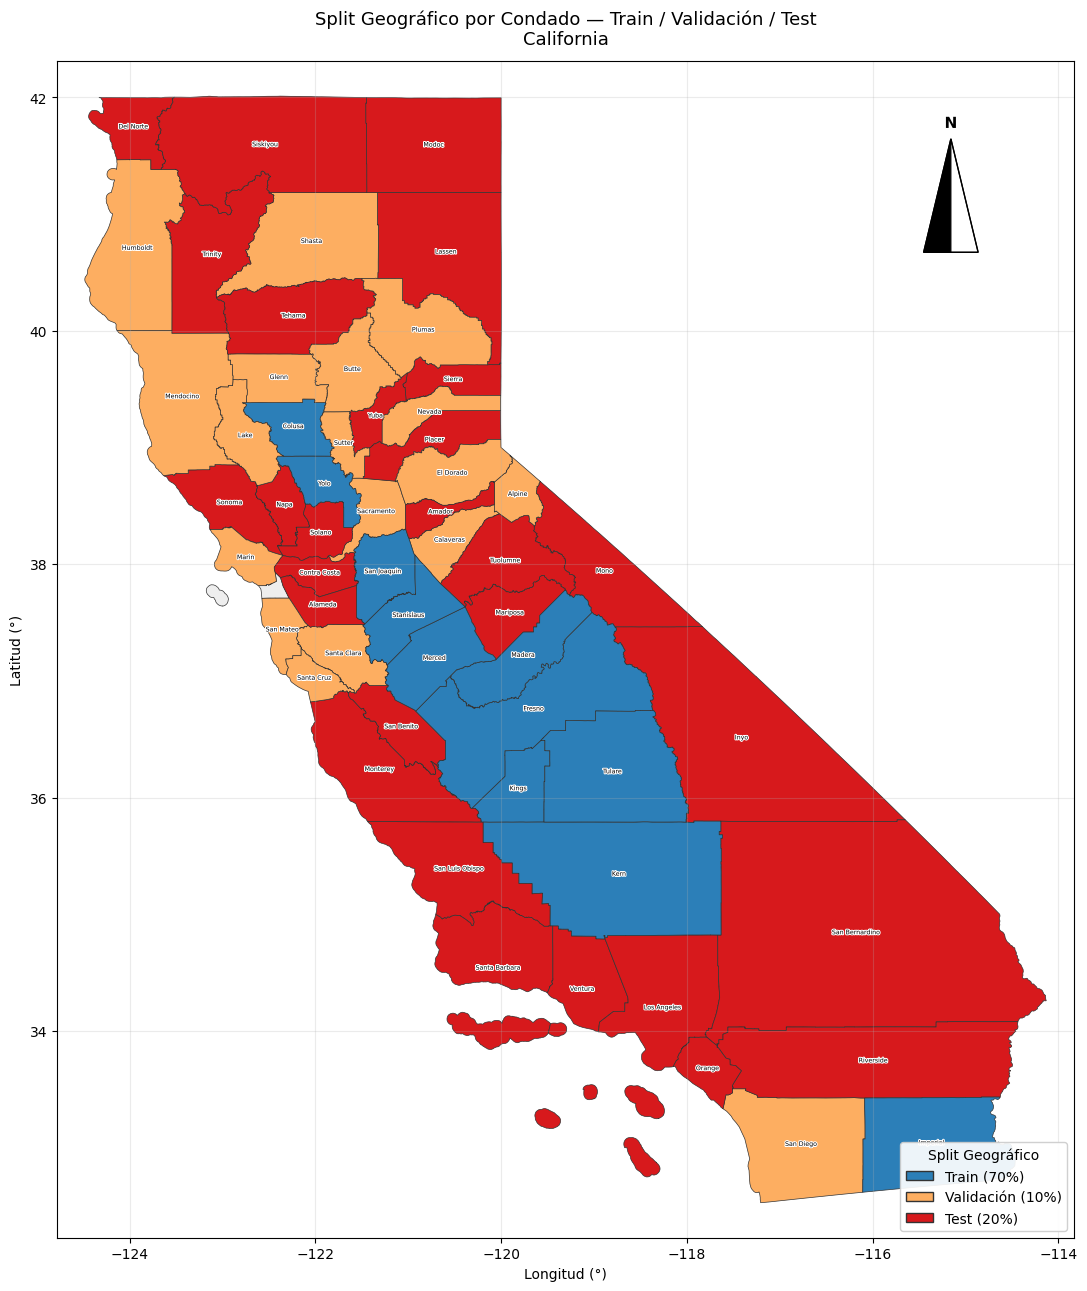

Mapa guardado: 10_split_geografico.png


In [15]:
# ── Mapa de verificación visual del split ──

colores_split = {
    'train': '#2c7fb8',   # azul
    'val':   '#fdae61',   # naranja
    'test':  '#d7191c'    # rojo
}

# Densidad por condado con su split
split_por_condado = (
    df_model
    .group_by(['county', 'split_zona'])
    .len()
    .to_pandas()
)
condado_split_map = dict(zip(
    split_por_condado['county'],
    split_por_condado['split_zona']
))

gdf_split = gdf_counties.copy()
gdf_split['split_zona'] = gdf_split['name'].map(condado_split_map)
gdf_split['color'] = gdf_split['split_zona'].map(colores_split)
gdf_split['color'] = gdf_split['color'].fillna('#eeeeee')

fig, ax = plt.subplots(figsize=(11, 14))

gdf_split.plot(
    ax=ax,
    color=gdf_split['color'],
    edgecolor='#333333',
    linewidth=0.5
)

# Etiquetas
for _, row in gdf_split.iterrows():
    if row['split_zona'] in colores_split:
        centroid = row['geometry'].centroid
        ax.annotate(
            row['name'],
            xy=(centroid.x, centroid.y),
            fontsize=4.5, ha='center', va='center',
            color='black', zorder=5,
            path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
        )
def agregar_norte(ax, x=0.95, y=0.97, size=0.045):
    """
    Añade una flecha de norte estilo cartográfico (mitad negra, mitad blanca)
    en coordenadas relativas al eje (0-1).

    Parámetros
    ----------
    ax   : eje de matplotlib
    x, y : posición del centro de la flecha (relativa al eje, 0-1)
    size : tamaño relativo de la flecha
    """
    fig = ax.get_figure()
    ax_bbox = ax.get_position()

    # Convertir coordenadas relativas al eje en coordenadas de figura
    cx = ax_bbox.x0 + x * ax_bbox.width
    cy = ax_bbox.y0 + y * ax_bbox.height

    h = size * 1.8   # altura de la flecha
    w = size * 0.55  # semi-ancho de la base

    # Mitad izquierda (negra)
    tri_izq = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx,     cy - h * 0.55]],
        transform=fig.transFigure,
        color='black', zorder=10, clip_on=False
    )

    # Mitad derecha (blanca con borde negro)
    tri_der = plt.Polygon(
        [[cx,     cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        color='white', zorder=10, clip_on=False,
        ec='black', linewidth=0.8
    )

    # Contorno exterior
    contorno = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        fill=False, ec='black', linewidth=1.0,
        zorder=11, clip_on=False
    )

    fig.add_artist(tri_izq)
    fig.add_artist(tri_der)
    fig.add_artist(contorno)

    # Letra N
    fig.text(
        cx, cy + h * 0.52,
        'N',
        transform=fig.transFigure,
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='black', zorder=12,
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colores_split['train'], edgecolor='#333', label='Train (70%)'),
    Patch(facecolor=colores_split['val'],   edgecolor='#333', label='Validación (10%)'),
    Patch(facecolor=colores_split['test'],  edgecolor='#333', label='Test (20%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          title='Split Geográfico', framealpha=0.92)

ax.set_title(
    'Split Geográfico por Condado — Train / Validación / Test\nCalifornia',
    fontsize=13, pad=12
)
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.grid(True, alpha=0.25)

minx, miny, maxx, maxy = gdf_counties.total_bounds
margen = 0.3
ax.set_xlim(minx - margen, maxx + margen)
ax.set_ylim(miny - margen, maxy + margen)

agregar_norte(ax, x=0.96, y=0.97)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '10_split_geografico.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Mapa guardado: 10_split_geografico.png')

# Preparación de datos (one-hot + matrices X/y)

In [16]:
features_base = [
    "tmax", "tmin", "ppt", "vpdmin", "vpdmax",
    "ph1to1h2o_r", "awc_r", "claytotal_r",
    "dbthirdbar_r", "sandtotal_r", "silttotal_r"
]

# One-hot encoding del cultivo en cada split
df_train_oh = df_train.to_dummies(columns=["crop_name"])
df_val_oh   = df_val.to_dummies(columns=["crop_name"])
df_test_oh  = df_test.to_dummies(columns=["crop_name"])

# Alinear columnas one-hot entre splits (por si algún cultivo falta en val/test)
todas_cols_cultivo = sorted(set(
    [c for c in df_train_oh.columns if c.startswith("crop_name_")] +
    [c for c in df_val_oh.columns   if c.startswith("crop_name_")] +
    [c for c in df_test_oh.columns  if c.startswith("crop_name_")]
))

def alinear_columnas(df_oh, todas_cols):
    faltantes = [c for c in todas_cols if c not in df_oh.columns]
    for c in faltantes:
        df_oh = df_oh.with_columns(pl.lit(0).cast(pl.UInt8).alias(c))
    return df_oh

df_train_oh = alinear_columnas(df_train_oh, todas_cols_cultivo)
df_val_oh   = alinear_columnas(df_val_oh,   todas_cols_cultivo)
df_test_oh  = alinear_columnas(df_test_oh,  todas_cols_cultivo)

features_modelo = features_base + todas_cols_cultivo

# Matrices X/y
X_train = df_train_oh.select(features_modelo).to_numpy()
y_train = df_train_oh.select("IAI").to_numpy().ravel()
X_val   = df_val_oh.select(features_modelo).to_numpy()
y_val   = df_val_oh.select("IAI").to_numpy().ravel()
X_test  = df_test_oh.select(features_modelo).to_numpy()
y_test  = df_test_oh.select("IAI").to_numpy().ravel()

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Total features: {len(features_modelo)} "
      f"({len(features_base)} base + {len(todas_cols_cultivo)} cultivos)")

# Verificación de nulos
for nombre, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{nombre}: {np.isnan(X).sum()} NaN")

X_train: (444628, 23) | X_val: (73034, 23) | X_test: (116290, 23)
Total features: 23 (11 base + 12 cultivos)
train: 0 NaN
val: 0 NaN
test: 0 NaN


# Función común de evaluación

In [17]:

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_v, y_v, predecir_fn=None):
    """
    Evalúa un modelo en train y validación.
    predecir_fn: función custom de predicción (para la red neuronal);
                 si None usa modelo.predict
    """
    pred = predecir_fn if predecir_fn else modelo.predict

    y_tr_pred = pred(X_tr)
    y_v_pred  = pred(X_v)

    metricas = {
        'modelo': nombre,
        'r2_train':  r2_score(y_tr, y_tr_pred),
        'r2_val':    r2_score(y_v, y_v_pred),
        'rmse_train': np.sqrt(mean_squared_error(y_tr, y_tr_pred)),
        'rmse_val':   np.sqrt(mean_squared_error(y_v, y_v_pred)),
        'mae_train':  mean_absolute_error(y_tr, y_tr_pred),
        'mae_val':    mean_absolute_error(y_v, y_v_pred),
    }
    metricas['gap_r2'] = metricas['r2_train'] - metricas['r2_val']

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"  R2   train: {metricas['r2_train']:.4f} | val: {metricas['r2_val']:.4f}")
    print(f"  RMSE train: {metricas['rmse_train']:.4f} | val: {metricas['rmse_val']:.4f}")
    print(f"  MAE  train: {metricas['mae_train']:.4f} | val: {metricas['mae_val']:.4f}")
    print(f"  Gap R2 (overfitting): {metricas['gap_r2']:.4f}")
    if metricas['gap_r2'] > 0.1:
        print(f"  ⚠ Posible overfitting (gap > 0.1)")
    return metricas

resultados_modelos = []

# MODELO BASE: RANDOM FOREST

In [19]:
#Random forest
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")

m_rf = evaluar_modelo("Random Forest", rf, X_train, y_train, X_val, y_val)
resultados_modelos.append(m_rf)

Tiempo de entrenamiento: 158.0s

  Random Forest
  R2   train: 0.9905 | val: 0.8467
  RMSE train: 0.0091 | val: 0.0362
  MAE  train: 0.0054 | val: 0.0253
  Gap R2 (overfitting): 0.1438
  ⚠ Posible overfitting (gap > 0.1)


# XGBOOOST

In [22]:
# XGBoost
t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")
print(f"Mejor iteración: {xgb_model.best_iteration}")

m_xgb = evaluar_modelo("XGBoost", xgb_model, X_train, y_train, X_val, y_val)
resultados_modelos.append(m_xgb)

Tiempo de entrenamiento: 5.2s
Mejor iteración: 96

  XGBoost
  R2   train: 0.9815 | val: 0.8751
  RMSE train: 0.0126 | val: 0.0327
  MAE  train: 0.0087 | val: 0.0201
  Gap R2 (overfitting): 0.1064
  ⚠ Posible overfitting (gap > 0.1)


# LIGHTGBM

In [25]:
# LightGBM
t0 = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)

print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")
print(f"Mejor iteración: {lgb_model.best_iteration_}")

m_lgb = evaluar_modelo("LightGBM", lgb_model, X_train, y_train, X_val, y_val)
resultados_modelos.append(m_lgb)

Tiempo de entrenamiento: 11.3s
Mejor iteración: 500


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



  LightGBM
  R2   train: 0.9928 | val: 0.9043
  RMSE train: 0.0079 | val: 0.0286
  MAE  train: 0.0049 | val: 0.0182
  Gap R2 (overfitting): 0.0885


# Red Neuronal (feedforward, enfoque A)

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# ── Escalado (solo para la red; los árboles no lo necesitan) ──
# IMPORTANTE: escalar solo las features base, NO las one-hot binarias
n_base = len(features_base)

scaler = StandardScaler()
X_train_sc = X_train.copy().astype(np.float32)
X_val_sc   = X_val.copy().astype(np.float32)

X_train_sc[:, :n_base] = scaler.fit_transform(X_train[:, :n_base])
X_val_sc[:, :n_base]   = scaler.transform(X_val[:, :n_base])

# ── Tensores y loaders ──
X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_v_t  = torch.tensor(X_val_sc, dtype=torch.float32)
y_v_t  = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=512, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_v_t, y_v_t),
    batch_size=512, shuffle=False
)

# ── Arquitectura feedforward ──
class RedIAI(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()   # IAI en [0, 1]
        )

    def forward(self, x):
        return self.net(x)

# ── Entrenamiento con early stopping ──
print("Entrenando Red Neuronal...")
t0 = time.time()

modelo_nn = RedIAI(input_dim=X_train_sc.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo_nn.parameters(), lr=0.001, weight_decay=1e-5)

mejor_val = float('inf')
mejor_pesos = None
patience, patience_count = 15, 0
MAX_EPOCHS = 100

for epoch in range(MAX_EPOCHS):
    modelo_nn.train()
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(modelo_nn(X_b), y_b)
        loss.backward()
        optimizer.step()

    # Validación
    modelo_nn.eval()
    val_loss, n = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            val_loss += criterion(modelo_nn(X_b), y_b).item() * len(X_b)
            n += len(X_b)
    val_loss /= n

    if val_loss < mejor_val:
        mejor_val = val_loss
        mejor_pesos = copy.deepcopy(modelo_nn.state_dict())
        patience_count = 0
    else:
        patience_count += 1

    if (epoch + 1) % 10 == 0:
        print(f"  Época {epoch+1}: val_loss={val_loss:.5f} | patience={patience_count}")

    if patience_count >= patience:
        print(f"  Early stopping en época {epoch+1}")
        break

modelo_nn.load_state_dict(mejor_pesos)
print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")

# ── Función de predicción para evaluar_modelo ──
def predecir_nn(X):
    modelo_nn.eval()
    # Escalar features base
    X_sc = X.copy().astype(np.float32)
    X_sc[:, :n_base] = scaler.transform(X[:, :n_base])
    X_t = torch.tensor(X_sc, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = modelo_nn(X_t).cpu().numpy().ravel()
    return pred

m_nn = evaluar_modelo(
    "Red Neuronal", modelo_nn,
    X_train, y_train, X_val, y_val,
    predecir_fn=predecir_nn
)
resultados_modelos.append(m_nn)

Dispositivo: cpu
Entrenando Red Neuronal...
  Época 10: val_loss=0.00235 | patience=3
  Época 20: val_loss=0.00243 | patience=1
  Época 30: val_loss=0.00220 | patience=3
  Época 40: val_loss=0.00227 | patience=13
  Early stopping en época 42
Tiempo de entrenamiento: 2237.6s

  Red Neuronal
  R2   train: 0.9660 | val: 0.7822
  RMSE train: 0.0171 | val: 0.0432
  MAE  train: 0.0119 | val: 0.0267
  Gap R2 (overfitting): 0.1838
  ⚠ Posible overfitting (gap > 0.1)


# Tabla comparativa


Comparación de modelos (ordenados por R2 validación):
shape: (4, 6)
┌───────────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ modelo        ┆ r2_train ┆ r2_val   ┆ gap_r2   ┆ rmse_val ┆ mae_val  │
│ ---           ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str           ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ LightGBM      ┆ 0.992814 ┆ 0.904321 ┆ 0.088493 ┆ 0.028634 ┆ 0.018226 │
│ XGBoost       ┆ 0.981477 ┆ 0.875077 ┆ 0.106401 ┆ 0.032719 ┆ 0.020107 │
│ Random Forest ┆ 0.990464 ┆ 0.846656 ┆ 0.143807 ┆ 0.03625  ┆ 0.025312 │
│ Red Neuronal  ┆ 0.965982 ┆ 0.782152 ┆ 0.18383  ┆ 0.043207 ┆ 0.026736 │
└───────────────┴──────────┴──────────┴──────────┴──────────┴──────────┘


C:\Users\lesli\AppData\Local\Temp\ipykernel_25224\2081948477.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(modelos, rotation=20, ha='right')


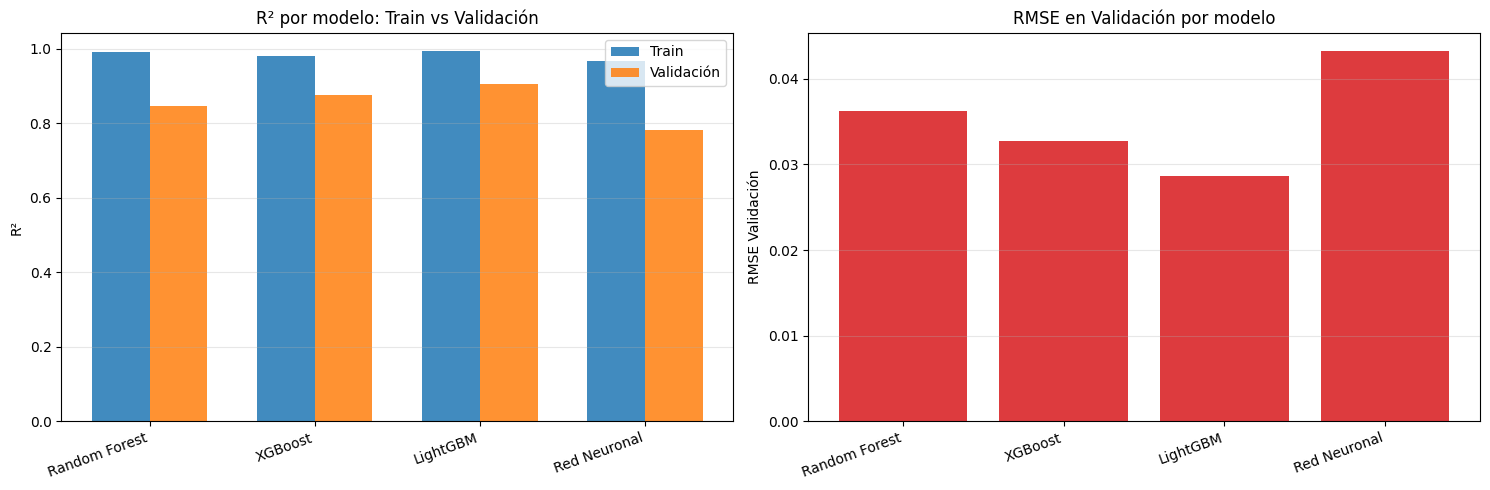

In [27]:
df_resultados = pl.DataFrame(resultados_modelos).select([
    'modelo', 'r2_train', 'r2_val', 'gap_r2',
    'rmse_val', 'mae_val'
]).sort('r2_val', descending=True)

print("\nComparación de modelos (ordenados por R2 validación):")
print(df_resultados)

# Gráfico comparativo
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

modelos = [m['modelo'] for m in resultados_modelos]
r2_tr = [m['r2_train'] for m in resultados_modelos]
r2_v  = [m['r2_val'] for m in resultados_modelos]

x = np.arange(len(modelos))
w = 0.35
axes[0].bar(x - w/2, r2_tr, w, label='Train', alpha=0.85)
axes[0].bar(x + w/2, r2_v, w, label='Validación', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, rotation=20, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_title('R² por modelo: Train vs Validación')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

rmse_v = [m['rmse_val'] for m in resultados_modelos]
axes[1].bar(modelos, rmse_v, alpha=0.85, color='#d7191c')
axes[1].set_xticklabels(modelos, rotation=20, ha='right')
axes[1].set_ylabel('RMSE Validación')
axes[1].set_title('RMSE en Validación por modelo')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '11_comparacion_modelos.png'), dpi=300, bbox_inches='tight')
plt.show()

In [29]:
import optuna
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
import lightgbm as lgb
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Grupos espaciales: condado de cada fila del train ──
# Necesitamos el array de condados alineado con X_train
grupos_condado = df_train_oh.select("county").to_numpy().ravel()

print(f"Condados únicos en train: {len(np.unique(grupos_condado))}")
print(f"Filas de train: {len(grupos_condado):,}")

# Número de folds para la CV espacial dentro del train
# Con ~11 condados en train, K=5 deja ~2 condados por fold de validación
N_FOLDS_CV = 5
gkf = GroupKFold(n_splits=N_FOLDS_CV)

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Condados únicos en train: 11
Filas de train: 444,628


In [30]:
def objetivo_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'random_state':     42,
        'n_jobs':           -1,
        'eval_metric':      'rmse',
        'early_stopping_rounds': 30
    }

    scores = []
    for idx_tr, idx_val in gkf.split(X_train, y_train, groups=grupos_condado):
        modelo = xgb.XGBRegressor(**params)
        modelo.fit(
            X_train[idx_tr], y_train[idx_tr],
            eval_set=[(X_train[idx_val], y_train[idx_val])],
            verbose=False
        )
        pred = modelo.predict(X_train[idx_val])
        scores.append(r2_score(y_train[idx_val], pred))

    return np.mean(scores)

print("Optimizando XGBoost (Optuna + CV espacial)...")
study_xgb = optuna.create_study(direction='maximize', study_name='xgb_spatial')
study_xgb.optimize(objetivo_xgb, n_trials=50, show_progress_bar=True)

print(f"\nMejor R² CV espacial: {study_xgb.best_value:.4f}")
print("Mejores hiperparámetros XGBoost:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

Optimizando XGBoost (Optuna + CV espacial)...


Best trial: 42. Best value: 0.923349: 100%|██████████| 50/50 [43:56<00:00, 52.72s/it] 


Mejor R² CV espacial: 0.9233
Mejores hiperparámetros XGBoost:
  n_estimators: 593
  max_depth: 10
  learning_rate: 0.047579710420982864
  subsample: 0.9831616038118414
  colsample_bytree: 0.6889138827475872
  reg_alpha: 0.002090592519693232
  reg_lambda: 0.5086664379120654
  min_child_weight: 5
  gamma: 0.008323088549136694


In [31]:
def objetivo_lgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'max_depth':        trial.suggest_int('max_depth', 4, 14),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state':     42,
        'n_jobs':           -1,
        'verbose':          -1
    }

    scores = []
    for idx_tr, idx_val in gkf.split(X_train, y_train, groups=grupos_condado):
        modelo = lgb.LGBMRegressor(**params)
        modelo.fit(
            X_train[idx_tr], y_train[idx_tr],
            eval_set=[(X_train[idx_val], y_train[idx_val])],
            callbacks=[lgb.early_stopping(30, verbose=False)]
        )
        pred = modelo.predict(X_train[idx_val])
        scores.append(r2_score(y_train[idx_val], pred))

    return np.mean(scores)

print("Optimizando LightGBM (Optuna + CV espacial)...")
study_lgb = optuna.create_study(direction='maximize', study_name='lgb_spatial')
study_lgb.optimize(objetivo_lgb, n_trials=50, show_progress_bar=True)

print(f"\nMejor R² CV espacial: {study_lgb.best_value:.4f}")
print("Mejores hiperparámetros LightGBM:")
for k, v in study_lgb.best_params.items():
    print(f"  {k}: {v}")

Optimizando LightGBM (Optuna + CV espacial)...


  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was 


Mejor R² CV espacial: 0.9424
Mejores hiperparámetros LightGBM:
  n_estimators: 671
  max_depth: 10
  num_leaves: 105
  learning_rate: 0.09132234617616686
  subsample: 0.6481833529071438
  colsample_bytree: 0.9354281729367406
  reg_alpha: 0.023216646917520935
  reg_lambda: 0.05865999304874439
  min_child_samples: 5


In [32]:
# ── LightGBM final ──
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

lgb_final = lgb.LGBMRegressor(**best_lgb_params)
lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)
m_lgb_opt = evaluar_modelo("LightGBM (optimizado)", lgb_final,
                            X_train, y_train, X_val, y_val)

# ── XGBoost final ──
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    'random_state': 42, 'n_jobs': -1,
    'eval_metric': 'rmse', 'early_stopping_rounds': 30
})

xgb_final = xgb.XGBRegressor(**best_xgb_params)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
m_xgb_opt = evaluar_modelo("XGBoost (optimizado)", xgb_final,
                            X_train, y_train, X_val, y_val)

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



  LightGBM (optimizado)
  R2   train: 0.9737 | val: 0.8424
  RMSE train: 0.0151 | val: 0.0368
  MAE  train: 0.0106 | val: 0.0225
  Gap R2 (overfitting): 0.1313
  ⚠ Posible overfitting (gap > 0.1)

  XGBoost (optimizado)
  R2   train: 0.9877 | val: 0.8814
  RMSE train: 0.0103 | val: 0.0319
  MAE  train: 0.0068 | val: 0.0207
  Gap R2 (overfitting): 0.1063
  ⚠ Posible overfitting (gap > 0.1)



Baseline vs Optimizado:
shape: (4, 5)
┌───────────────────────┬──────────┬──────────┬──────────┬──────────┐
│ modelo                ┆ r2_val   ┆ gap_r2   ┆ rmse_val ┆ mae_val  │
│ ---                   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str                   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════════════════════╪══════════╪══════════╪══════════╪══════════╡
│ LightGBM              ┆ 0.904321 ┆ 0.088493 ┆ 0.028634 ┆ 0.018226 │
│ LightGBM (optimizado) ┆ 0.842351 ┆ 0.131299 ┆ 0.036755 ┆ 0.022537 │
│ XGBoost               ┆ 0.875077 ┆ 0.106401 ┆ 0.032719 ┆ 0.020107 │
│ XGBoost (optimizado)  ┆ 0.881416 ┆ 0.106334 ┆ 0.031878 ┆ 0.020662 │
└───────────────────────┴──────────┴──────────┴──────────┴──────────┘


C:\Users\lesli\AppData\Local\Temp\ipykernel_25224\1044720537.py:16: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_lgb, ax=axes[0])


TypeError: plot_optimization_history() got an unexpected keyword argument 'ax'

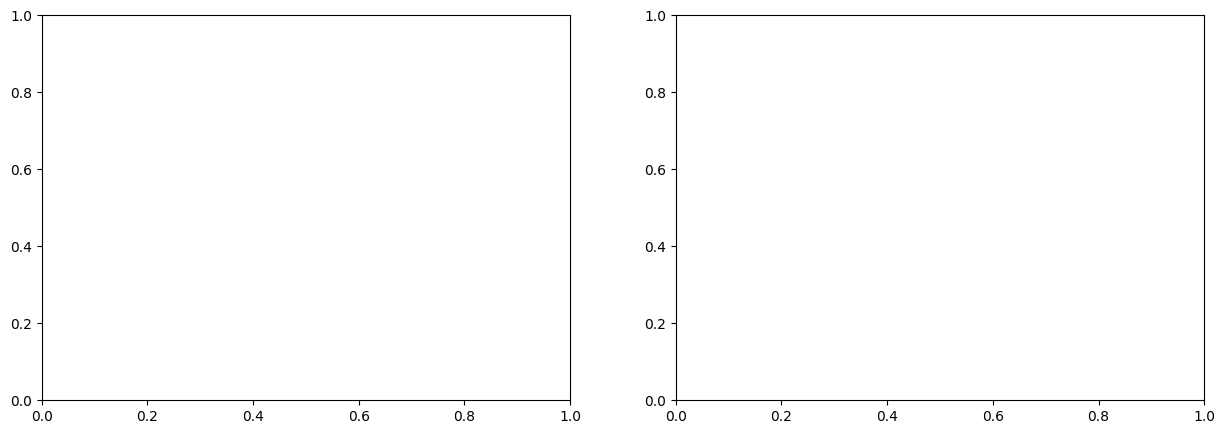

In [33]:

comparacion = pl.DataFrame([
    m_lgb,      # baseline LightGBM (del bloque anterior)
    m_lgb_opt,  # optimizado
    m_xgb,      # baseline XGBoost
    m_xgb_opt   # optimizado
]).select(['modelo', 'r2_val', 'gap_r2', 'rmse_val', 'mae_val'])

print("\nBaseline vs Optimizado:")
print(comparacion)

# Visualización de historia de optimización
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

optuna.visualization.matplotlib.plot_optimization_history(study_lgb, ax=axes[0])
axes[0].set_title('Optuna - LightGBM')

optuna.visualization.matplotlib.plot_optimization_history(study_xgb, ax=axes[1])
axes[1].set_title('Optuna - XGBoost')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '12_optuna_history.png'), dpi=300, bbox_inches='tight')
plt.show()

In [34]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
import numpy as np

def cv_espacial_score(modelo_clase, params, X, y, grupos, n_folds=5):
    """Evalúa un modelo con CV espacial y devuelve R2 medio y std."""
    gkf = GroupKFold(n_splits=n_folds)
    scores = []
    for idx_tr, idx_val in gkf.split(X, y, groups=grupos):
        modelo = modelo_clase(**params)
        if 'early_stopping_rounds' in params or hasattr(modelo, 'best_iteration_'):
            try:
                modelo.fit(X[idx_tr], y[idx_tr],
                           eval_set=[(X[idx_val], y[idx_val])], verbose=False)
            except TypeError:
                modelo.fit(X[idx_tr], y[idx_tr])
        else:
            modelo.fit(X[idx_tr], y[idx_tr])
        pred = modelo.predict(X[idx_val])
        scores.append(r2_score(y[idx_val], pred))
    return np.mean(scores), np.std(scores)

# Comparar ambos optimizados con la misma CV
r2_lgb_cv, std_lgb = cv_espacial_score(
    lgb.LGBMRegressor, best_lgb_params, X_train, y_train, grupos_condado
)
r2_xgb_cv, std_xgb = cv_espacial_score(
    xgb.XGBRegressor, best_xgb_params, X_train, y_train, grupos_condado
)

print(f"LightGBM optimizado - CV espacial: {r2_lgb_cv:.4f} ± {std_lgb:.4f}")
print(f"XGBoost optimizado  - CV espacial: {r2_xgb_cv:.4f} ± {std_xgb:.4f}")

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

LightGBM optimizado - CV espacial: 0.9424 ± 0.0268
XGBoost optimizado  - CV espacial: 0.9233 ± 0.0340


In [35]:
import joblib
import os
import json

# Directorio para modelos
MODELS_DIR = '../modelos/'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── 1. Modelos de árboles (joblib) ──
joblib.dump(rf,        os.path.join(MODELS_DIR, 'rf_baseline.pkl'))
joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'xgb_baseline.pkl'))
joblib.dump(lgb_model, os.path.join(MODELS_DIR, 'lgb_baseline.pkl'))
joblib.dump(xgb_final, os.path.join(MODELS_DIR, 'xgb_optimizado.pkl'))
joblib.dump(lgb_final, os.path.join(MODELS_DIR, 'lgb_optimizado.pkl'))

# ── 2. Red neuronal (state_dict de PyTorch) ──
torch.save(modelo_nn.state_dict(), os.path.join(MODELS_DIR, 'nn_baseline.pth'))

# ── 3. Scaler de la red neuronal ──
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler_nn.pkl'))

# ── 4. Estudios de Optuna (para revisar después) ──
joblib.dump(study_lgb, os.path.join(MODELS_DIR, 'study_lgb.pkl'))
joblib.dump(study_xgb, os.path.join(MODELS_DIR, 'study_xgb.pkl'))

# ── 5. Mejores hiperparámetros (JSON legible) ──
with open(os.path.join(MODELS_DIR, 'best_params.json'), 'w') as f:
    json.dump({
        'lgb': study_lgb.best_params,
        'xgb': study_xgb.best_params,
        'lgb_cv_r2': study_lgb.best_value,
        'xgb_cv_r2': study_xgb.best_value
    }, f, indent=2)

# ── 6. Lista de features (orden importa para predicción) ──
with open(os.path.join(MODELS_DIR, 'features_modelo.json'), 'w') as f:
    json.dump({
        'features_base': features_base,
        'features_modelo': features_modelo,
        'cols_cultivo': todas_cols_cultivo
    }, f, indent=2)

print("Modelos y objetos guardados en:", MODELS_DIR)
print(os.listdir(MODELS_DIR))

Modelos y objetos guardados en: ../modelos/
['best_params.json', 'features_modelo.json', 'lgb_baseline.pkl', 'lgb_optimizado.pkl', 'nn_baseline.pth', 'rf_baseline.pkl', 'scaler_nn.pkl', 'study_lgb.pkl', 'study_xgb.pkl', 'xgb_baseline.pkl', 'xgb_optimizado.pkl']


In [36]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ── Evaluación FINAL en test (zonas no vistas) ──
# Reentrenar LightGBM en TODO el train con los mejores params
import lightgbm as lgb

modelo_definitivo = lgb.LGBMRegressor(**best_lgb_params)
modelo_definitivo.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

# Predicción en test
y_test_pred = modelo_definitivo.predict(X_test)

# Métricas finales
r2_test   = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)

print("="*55)
print("  EVALUACIÓN FINAL EN TEST — LightGBM optimizado")
print("  (condados geográficamente distintos, nunca vistos)")
print("="*55)
print(f"  R²   test: {r2_test:.4f}")
print(f"  RMSE test: {rmse_test:.4f}")
print(f"  MAE  test: {mae_test:.4f}")
print("="*55)
print(f"\n  Referencia CV espacial: 0.9424 ± 0.0268")
print(f"  Diferencia test vs CV:  {r2_test - 0.9424:+.4f}")

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  EVALUACIÓN FINAL EN TEST — LightGBM optimizado
  (condados geográficamente distintos, nunca vistos)
  R²   test: 0.7145
  RMSE test: 0.0569
  MAE  test: 0.0348

  Referencia CV espacial: 0.9424 ± 0.0268
  Diferencia test vs CV:  -0.2279


In [37]:
# Comparar las tres métricas clave del modelo definitivo
y_train_pred = modelo_definitivo.predict(X_train)
y_val_pred   = modelo_definitivo.predict(X_val)
y_test_pred  = modelo_definitivo.predict(X_test)

r2_tr   = r2_score(y_train, y_train_pred)
r2_v    = r2_score(y_val, y_val_pred)
r2_te   = r2_score(y_test, y_test_pred)

print("Diagnóstico de sobreajuste — LightGBM definitivo")
print(f"  R² Train:         {r2_tr:.4f}")
print(f"  R² CV espacial:   0.9424 ± 0.0268")
print(f"  R² Validación:    {r2_v:.4f}")
print(f"  R² Test:          {r2_te:.4f}")
print(f"\n  Gap Train-Test:   {r2_tr - r2_te:.4f}")
print(f"  Gap CV-Test:      {0.9424 - r2_te:+.4f}")

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Diagnóstico de sobreajuste — LightGBM definitivo
  R² Train:         0.9737
  R² CV espacial:   0.9424 ± 0.0268
  R² Validación:    0.8424
  R² Test:          0.7145

  Gap Train-Test:   0.2592
  Gap CV-Test:      +0.2279


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


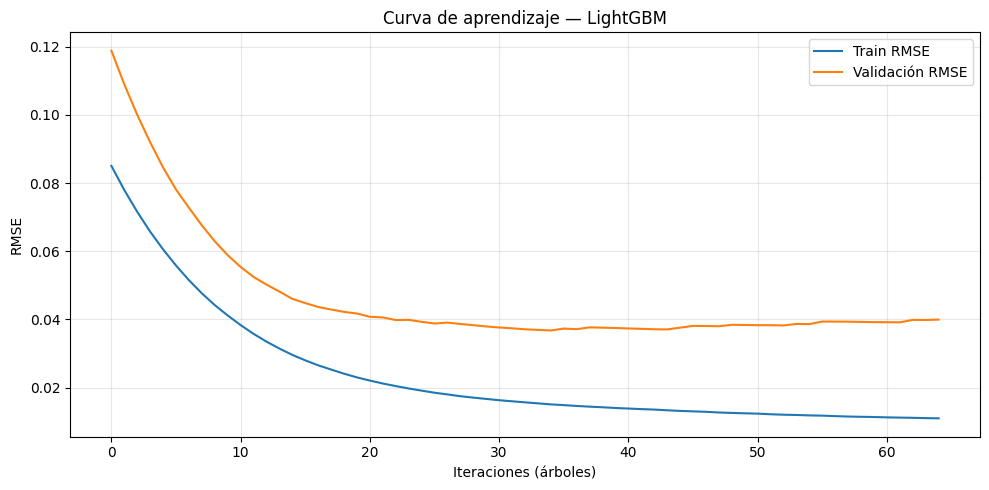

In [38]:
# Reentrenar capturando el historial de evaluación
modelo_lc = lgb.LGBMRegressor(**best_lgb_params)
modelo_lc.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)]
)

resultados = modelo_lc.evals_result_
plt.figure(figsize=(10, 5))
plt.plot(resultados['train']['rmse'], label='Train RMSE')
plt.plot(resultados['val']['rmse'], label='Validación RMSE')
plt.xlabel('Iteraciones (árboles)')
plt.ylabel('RMSE')
plt.title('Curva de aprendizaje — LightGBM')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# ── Guardar el modelo definitivo ──
import joblib, os
joblib.dump(modelo_definitivo, os.path.join(MODELS_DIR, 'modelo_definitivo_lgb.pkl'))
print("Modelo definitivo guardado.")

Modelo definitivo guardado.


In [40]:
# Condado de cada fila de test
condados_test_arr = df_test_oh.select("county").to_numpy().ravel()

# R2 por condado
resultados_condado = []
for condado in np.unique(condados_test_arr):
    mask = condados_test_arr == condado
    if mask.sum() >= 30:  # mínimo de observaciones
        r2_c = r2_score(y_test[mask], y_test_pred[mask])
        resultados_condado.append({
            'condado': condado,
            'n_obs': int(mask.sum()),
            'r2': r2_c
        })

df_r2_condado = pl.DataFrame(resultados_condado).sort('r2', descending=True)
print("R² por condado en test:")
print(df_r2_condado)

R² por condado en test:
shape: (23, 3)
┌─────────────────┬───────┬───────────┐
│ condado         ┆ n_obs ┆ r2        │
│ ---             ┆ ---   ┆ ---       │
│ str             ┆ i64   ┆ f64       │
╞═════════════════╪═══════╪═══════════╡
│ Riverside       ┆ 16429 ┆ 0.948358  │
│ San Bernardino  ┆ 3227  ┆ 0.944655  │
│ Solano          ┆ 9006  ┆ 0.927117  │
│ Tehama          ┆ 4777  ┆ 0.92066   │
│ Contra Costa    ┆ 2227  ┆ 0.911924  │
│ Alameda         ┆ 426   ┆ 0.819265  │
│ Yuba            ┆ 6476  ┆ 0.807263  │
│ Placer          ┆ 2021  ┆ 0.795856  │
│ Los Angeles     ┆ 293   ┆ 0.787572  │
│ San Benito      ┆ 1205  ┆ 0.774951  │
│ Ventura         ┆ 482   ┆ 0.73324   │
│ Amador          ┆ 306   ┆ 0.644188  │
│ Monterey        ┆ 8531  ┆ 0.573526  │
│ San Luis Obispo ┆ 5151  ┆ 0.525638  │
│ Santa Barbara   ┆ 3244  ┆ 0.463067  │
│ Lassen          ┆ 9870  ┆ 0.457986  │
│ Siskiyou        ┆ 10174 ┆ 0.415958  │
│ Sierra          ┆ 378   ┆ 0.321622  │
│ Mono            ┆ 11374 ┆ 0.007413  │
│

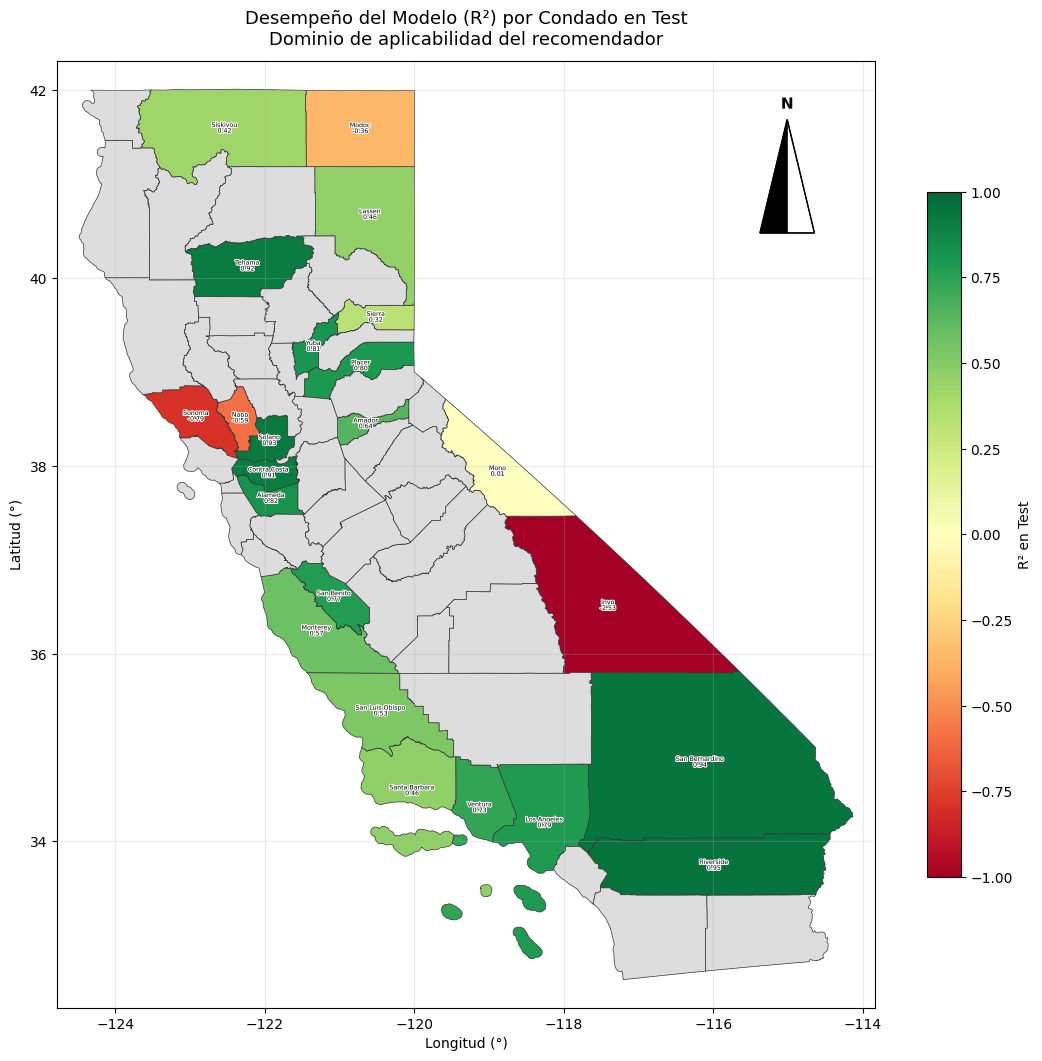

In [41]:
# Unir R² por condado al shapefile
df_r2_pd = df_r2_condado.to_pandas()
r2_map = dict(zip(df_r2_pd['condado'], df_r2_pd['r2']))

gdf_r2 = gdf_counties.copy()
gdf_r2['r2_test'] = gdf_r2['name'].map(r2_map)

fig, ax = plt.subplots(figsize=(11, 14))

gdf_r2.plot(
    column='r2_test',
    ax=ax,
    cmap='RdYlGn',
    vmin=-1, vmax=1,          # recortar extremos para legibilidad
    legend=True,
    legend_kwds={'label': 'R² en Test', 'shrink': 0.5},
    edgecolor='#333333',
    linewidth=0.5,
    missing_kwds={'color': '#dddddd', 'label': 'No en test'}
)

for _, row in gdf_r2.iterrows():
    if row['name'] in r2_map:
        centroid = row['geometry'].centroid
        ax.annotate(
            f"{row['name']}\n{r2_map[row['name']]:.2f}",
            xy=(centroid.x, centroid.y),
            fontsize=4.5, ha='center', va='center',
            color='black', zorder=5,
            path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
        )

ax.set_title('Desempeño del Modelo (R²) por Condado en Test\nDominio de aplicabilidad del recomendador',
             fontsize=13, pad=12)
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.grid(True, alpha=0.25)

minx, miny, maxx, maxy = gdf_counties.total_bounds
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)

agregar_norte(ax, x=0.96, y=0.97)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '13_r2_por_condado_test.png'), dpi=300, bbox_inches='tight')
plt.show()